# Análise Estatística da Estratégia (Lucro_Lay)
Este notebook executa uma análise completa com base nos valores da coluna `Lucro_Lay`, incluindo estatísticas descritivas, distribuição (Normal e KDE), simulação Monte Carlo e drawdown máximo.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import skew, kurtosis, gaussian_kde

# Carregar os dados
df = pd.read_csv("./dados/lucro_por_operacao.csv")
vals = df["Lucro_Lay"].dropna().to_numpy()


## Estatísticas Descritivas

In [2]:
mu = vals.mean()
sigma = vals.std(ddof=1)
assimetria = skew(vals)
curtose_excesso = kurtosis(vals)
curtose_total = kurtosis(vals, fisher=False)

pd.DataFrame({
    "Métrica": [
        "Média por operação",
        "Desvio padrão",
        "Assimetria",
        "Curtose (excesso)",
        "Curtose total"
    ],
    "Valor": [mu, sigma, assimetria, curtose_excesso, curtose_total]
})


,Métrica,Valor
0,Média por operação,0.035323
1,Desvio padrão,0.432030
2,Assimetria,-1.946608
3,Curtose (excesso),1.886128
4,Curtose total,4.886128


## Histograma com Curva Normal Ajustada

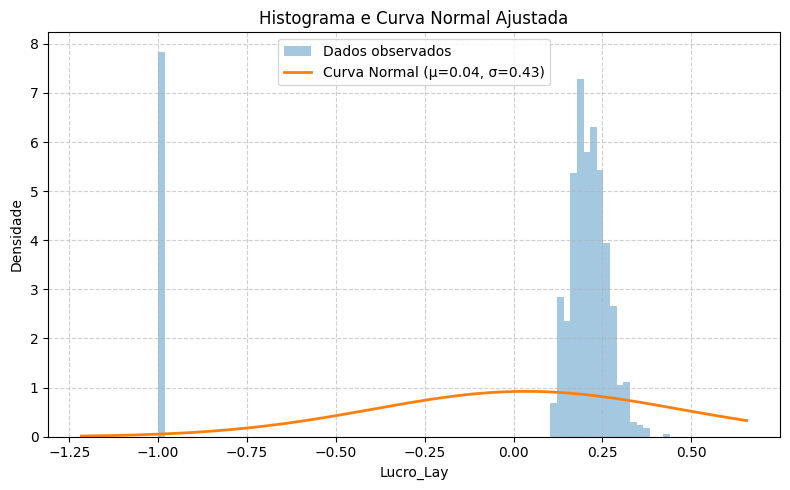

In [3]:
x = np.linspace(vals.min() - 0.5*sigma, vals.max() + 0.5*sigma, 400)
pdf_normal = (1 / (sigma * np.sqrt(2*np.pi))) * np.exp(-0.5 * ((x - mu)/sigma)**2)

plt.figure(figsize=(8,5))
plt.hist(vals, bins='auto', density=True, alpha=0.4, label="Dados observados")
plt.plot(x, pdf_normal, linewidth=2, label=f"Curva Normal (μ={mu:.2f}, σ={sigma:.2f})")
plt.xlabel("Lucro_Lay")
plt.ylabel("Densidade")
plt.title("Histograma e Curva Normal Ajustada")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


## Estimativas de Probabilidades via KDE

In [4]:
kde = gaussian_kde(vals)
x_kde = np.linspace(vals.min() - 1, vals.max() + 1, 500)
pdf_kde = kde(x_kde)
dx = x_kde[1] - x_kde[0]

prob_perda = np.sum(pdf_kde[x_kde < 0]) * dx
prob_ganho_2 = np.sum(pdf_kde[x_kde > 2]) * dx
prob_perda_2 = np.sum(pdf_kde[x_kde < -2]) * dx

pd.DataFrame({
    "Evento": [
        "Probabilidade de perda (< 0)",
        "Probabilidade de ganho > 2",
        "Probabilidade de perda < -2"
    ],
    "Probabilidade (%)": [
        prob_perda * 100,
        prob_ganho_2 * 100,
        prob_perda_2 * 100
    ]
})


,Evento,Probabilidade (%)
0,Probabilidade de perda (< 0),18.261158
1,Probabilidade de ganho > 2,0.000000
2,Probabilidade de perda < -2,0.000000


## Simulação Monte Carlo (500 operações)

In [5]:
np.random.seed(42)
n_simulacoes = 10000
n_passos = 500
simulacoes = kde.resample(n_simulacoes * n_passos).reshape(n_simulacoes, n_passos)
saldos_finais = simulacoes.sum(axis=1)

pd.DataFrame({
    "Métrica": [
        "Probabilidade de terminar positivo",
        "Lucro final médio",
        "Pior cenário",
        "Melhor cenário"
    ],
    "Valor": [
        f"{(saldos_finais > 0).mean() * 100:.2f}%",
        f"{saldos_finais.mean():.2f}",
        f"{saldos_finais.min():.2f}",
        f"{saldos_finais.max():.2f}"
    ]
})


,Métrica,Valor
0,Probabilidade de terminar positivo,96.02%
1,Lucro final médio,17.67
2,Pior cenário,-22.21
3,Melhor cenário,54.85


## Drawdown Máximo

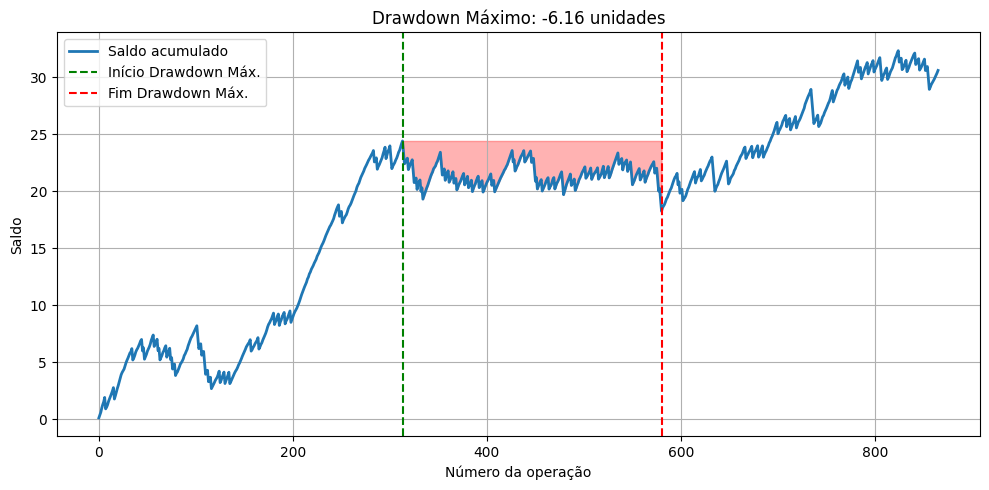

In [6]:
saldos_acumulados = np.cumsum(vals)
max_anteriores = np.maximum.accumulate(saldos_acumulados)
drawdowns = saldos_acumulados - max_anteriores

fim_dd = np.argmin(drawdowns)
inicio_dd = np.argmax(saldos_acumulados[:fim_dd+1])
drawdown_maximo = drawdowns.min()

plt.figure(figsize=(10,5))
plt.plot(saldos_acumulados, label="Saldo acumulado", linewidth=2)
plt.axvline(inicio_dd, color='green', linestyle='--', label="Início Drawdown Máx.")
plt.axvline(fim_dd, color='red', linestyle='--', label="Fim Drawdown Máx.")
plt.fill_between(range(inicio_dd, fim_dd+1),
                 saldos_acumulados[inicio_dd:fim_dd+1],
                 max_anteriores[inicio_dd:fim_dd+1],
                 color='red', alpha=0.3)
plt.title(f"Drawdown Máximo: {drawdown_maximo:.2f} unidades")
plt.xlabel("Número da operação")
plt.ylabel("Saldo")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
